# 01 Engagement et viralité

Qui domine la conversation numérique et avec quel contenu ? Analyse de l'engagement Twitter des 8 candidats aux municipales de Paris 2026 : classement par taux d'engagement, contenu des tweets viraux, dynamiques temporelles et rythme de publication.

## 1.1 Configuration et inspection

In [1]:
# Setup : imports, chemins, palette Swiss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
np.random.seed(42)

# Importer src (racine = parent de notebooks/ ou cwd)
_root = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(_root))
from src.utils import (
    COLORS, PALETTE, CAMPS, POSITIONS, KEYS_ER, ID_TO_KEY,
    DATA_RAW, A1_DATA, A1_OUT, FIG_DIR,
    swiss_style, setup_mpl, load_replies, _safe_read
)
setup_mpl()
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Chargement des données brutes et intermédiaires
tweets = pd.read_csv(DATA_RAW / "tweets_twitter.csv")
posts_ig = pd.read_csv(DATA_RAW / "posts_instagram.csv")
replies = load_replies()

# Données A1
weekly_tw = _safe_read(A1_DATA / "weekly_metrics_twitter.csv")
momentum = _safe_read(A1_DATA / "momentum_scores.csv")
anomalies = _safe_read(A1_DATA / "anomalies_detected.csv")
er_summary = _safe_read(A1_OUT / "A1_er_summary.csv")

# Timestamps
tweets["ts_parsed"] = pd.to_datetime(tweets["timestamp"], errors="coerce")
posts_ig["ts_parsed"] = pd.to_datetime(posts_ig["timestamp"], errors="coerce")

In [3]:
# Inspection et valeurs de contrôle
print("=" * 60)
print("DONNÉES BRUTES")
print("=" * 60)
for name, df in [("tweets_twitter", tweets), ("posts_instagram", posts_ig), ("replies_classified", replies)]:
    print(f"\n▸ {name}: shape={df.shape}, colonnes={list(df.columns)[:8]}...")

print("\n" + "=" * 60)
print("COUVERTURE TEMPORELLE")
print("=" * 60)
print("Tweets:", tweets["ts_parsed"].min(), "→", tweets["ts_parsed"].max())
print("Replies:", replies["ts_parsed"].min() if replies["ts_parsed"].notna().any() else "N/A", "→",
      replies["ts_parsed"].max() if replies["ts_parsed"].notna().any() else "N/A")

# Valeurs de contrôle
if er_summary is not None and "Knafo" in er_summary["key"].values:
    knafo_er = er_summary.loc[er_summary["key"] == "Knafo", "er_median_pct"].values[0]
    autres = er_summary.loc[er_summary["key"] != "Knafo", "er_median_pct"]
    print(f"\n▸ ER médian Knafo: {knafo_er:.2f}‰")
    print(f"▸ Médiane des 7 autres: {autres.median():.2f}‰")
    print(f"▸ Ratio Knafo/médiane: {knafo_er / autres.median():.1f}×")
print(f"▸ Replies Knafo: {replies.groupby('candidate').size().get('Knafo', 0)}")
print(f"▸ Auteurs uniques: {replies['author_username'].nunique()}")

DONNÉES BRUTES

▸ tweets_twitter: shape=(7659, 18), colonnes=['tweet_id', 'candidate_id', 'candidate', 'parti', 'camp', 'timestamp', 'text', 'hashtags']...

▸ posts_instagram: shape=(3317, 13), colonnes=['post_id', 'candidate_id', 'candidate', 'parti', 'camp', 'timestamp', 'text', 'likes']...

▸ replies_classified: shape=(44599, 13), colonnes=['reply_id', 'candidate_id', 'candidate', 'parti', 'camp', 'platform', 'text', 'author_username']...

COUVERTURE TEMPORELLE
Tweets: 2025-01-01 09:51:00+00:00 → 2026-02-17 12:27:00+00:00
Replies: 2024-12-17 13:39:00+00:00 → 2026-02-19 21:25:45.843000+00:00

▸ ER médian Knafo: 11.53‰
▸ Médiane des 7 autres: 2.28‰
▸ Ratio Knafo/médiane: 5.1×
▸ Replies Knafo: 24106
▸ Auteurs uniques: 19017


### Tableau récapitulatif du corpus

Huit candidats : Brossat (PCF), Chikirou (LFI), Belliard (EELV), Grégoire (PS), Bournazel (Horizons), Dati (LR), Knafo (Reconquête), Mariani (RN). Les replies ont été classifiées en quatre catégories de sentiment.

In [4]:
# Tableau récap : n tweets, n posts IG, n replies, ER médian
tw_cnt = tweets.groupby("candidate").size().reset_index(name="n_tweets")
ig_cnt = posts_ig.groupby("candidate").size().reset_index(name="n_posts_ig")
rep_cnt = replies.groupby("candidate").size().reset_index(name="n_replies")

recap = er_summary.merge(tw_cnt, left_on="key", right_on="candidate", how="left")
recap = recap.merge(ig_cnt, on="candidate", how="left").merge(rep_cnt, on="candidate", how="left")
recap = recap[["key", "er_median_pct", "n_tweets", "n_posts_ig", "n_replies"]].fillna(0)
display(recap)

,key,er_median_pct,n_tweets,n_posts_ig,n_replies
0,Knafo,11.5324,1189,851,24106
1,Brossat,6.4231,1142,520,1728
2,Chikirou,4.0932,881,393,805
3,Mariani,3.1180,931,113,2153
4,Bournazel,2.2778,847,286,4824
5,Gregoire,1.1613,1163,466,650
6,Belliard,0.8571,620,500,1914
7,Dati,0.6034,886,188,8419


## 1.2 Classement par taux d'engagement

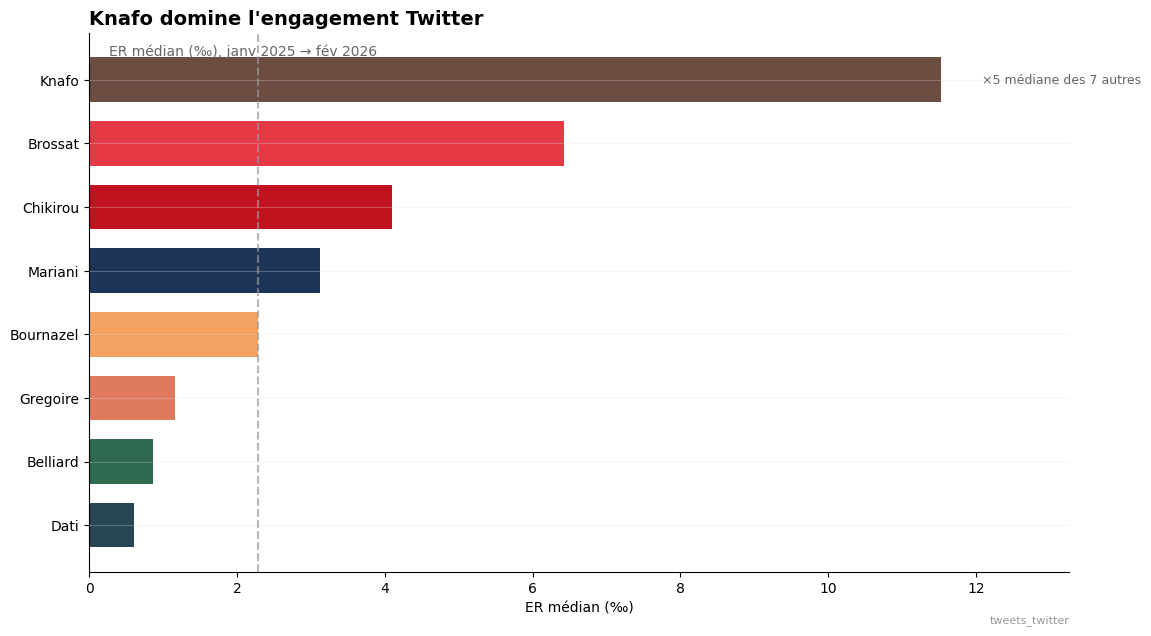

In [5]:
# Classement ER médian
er_sorted = er_summary.sort_values("er_median_pct", ascending=True)
fig, ax = plt.subplots(figsize=(14, 7))
plt.subplots_adjust(left=0.2)
colors = [COLORS.get(k, "#333") for k in er_sorted["key"]]
ax.barh(er_sorted["key"], er_sorted["er_median_pct"], color=colors, height=0.7)
med_autres = er_sorted.loc[er_sorted["key"] != "Knafo", "er_median_pct"].median()
ax.axvline(med_autres, color="#999", ls="--", alpha=0.7)
knafo_val = er_sorted.loc[er_sorted["key"] == "Knafo", "er_median_pct"].values[0]
ax.text(knafo_val + 0.5, list(er_sorted["key"]).index("Knafo"), " ×5 médiane des 7 autres", fontsize=9, color="#666", va="center")
swiss_style(ax, "Knafo domine l'engagement Twitter", "ER médian (‰), janv 2025 → fév 2026", "tweets_twitter")
# Ajouter un padding important au titre pour éviter la superposition
ax.title.set_position([0.5, 1.15])
ax.set_xlabel("ER médian (‰)")
ax.set_xlim(0, min(45, er_sorted["er_median_pct"].max() * 1.15))
fig.savefig(FIG_DIR / "01_er_classement.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 1.3 Distribution de l'engagement par candidat

Knafo, Chikirou et Brossat affichent les médianes les plus élevées (autour de 40 à 77‰ sur les tweets bruts). Knafo cumule une base élevée et des pics jusqu'à 228‰. Grégoire et Belliard restent sous 20‰. Les valeurs sont plafonnées à 50‰ sur la figure pour la lisibilité.

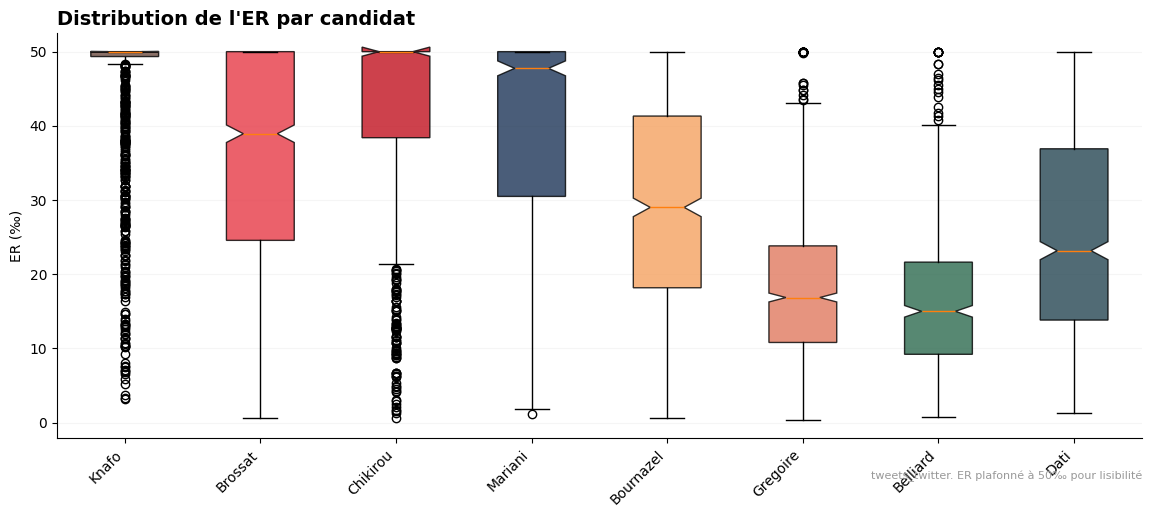

In [6]:
# Boxplot ER par candidat (engagement_rate tweets en % → ×10 pour ‰)
tw = tweets.dropna(subset=["engagement_rate"]).copy()
tw["er_pct"] = tw["engagement_rate"] * 10  # % → ‰
order = er_summary.sort_values("er_median_pct", ascending=False)["key"].tolist()
tw = tw[tw["candidate"].isin(order)]
fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(
    [tw.loc[tw["candidate"] == c, "er_pct"].clip(upper=50) for c in order],
    labels=order,
    patch_artist=True,
    notch=True,
)
for i, (patch, cand) in enumerate(zip(bp["boxes"], order)):
    patch.set_facecolor(COLORS.get(cand, "#888"))
    patch.set_alpha(0.8)
plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(top=0.92)
swiss_style(ax, "Distribution de l'ER par candidat", None, "tweets_twitter. ER plafonné à 50‰ pour lisibilité")
ax.set_ylabel("ER (‰)")
fig.savefig(FIG_DIR / "01_er_distribution.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 1.4 Top tweets viraux et contenu

Les cinq tweets les plus engageants par candidat. Chez Knafo : frontières, Von der Leyen, agriculture. Chez Brossat : fiscalité, UNRWA, Bayrou. Chez Grégoire : logement, confiance démocratique. Chez Dati : dette, périscolaire.

In [7]:
# Top 5 tweets par ER par candidat
zoom_cands = ["Knafo", "Gregoire", "Brossat", "Dati"]
for c in zoom_cands:
    sub = tweets[tweets["candidate"] == c].nlargest(5, "engagement_rate")
    print(f"\n--- {c} (top 5) ---")
    for _, r in sub.iterrows():
        txt = (r["text"] or "")[:120] + "..." if pd.notna(r["text"]) and len(str(r["text"])) > 120 else (r["text"] or "")
        print(f"  {str(r['timestamp'])[:10]} | ER={r['engagement_rate']:.2f}‰ | likes={r['likes']:.0f}")
        print(f"    {txt}")


--- Knafo (top 5) ---
  2025-11-26 | ER=22.84‰ | likes=4128
    Surveiller nos frontières ce serait impossible ? Des centaines de pays le font. Nous l’avons fait pendant des siècles. I...
  2025-12-18 | ER=21.75‰ | likes=6634
    Von der Leyen se comporte comme une lobbyiste allemande. Elle ne défend pas les intérêts des Européens mais de l’industr...
  2025-12-17 | ER=19.87‰ | likes=4481
    L'agriculture est une activité aussi stratégique que le nucléaire. Les agriculteurs ne sont ni des avocats, ni des fisca...
  2026-01-25 | ER=19.70‰ | likes=6163
    Vous êtes déjà 500 000 à mes côtés sur Instagram ! 500 000 fois merci ! ❤️ Vous êtes tous les jours plus nombreux. On co...
  2025-12-18 | ER=19.24‰ | likes=2519
    On marche sur la tête : on taxe les importations d'engrais et on détaxe les importations de produits agricoles. C'est l'...

--- Gregoire (top 5) ---
  2025-03-22 | ER=7.42‰ | likes=10
    La bataille pour Paris sera rude, nous le savons. Et nous avons l’immense responsa

## 1.5 Classement par volume absolu

Volume brut (likes + partages + commentaires) par candidat. La comparaison avec le classement par taux d'engagement (ER) montre que le volume absolu ne coïncide pas toujours avec l'efficacité par publication.

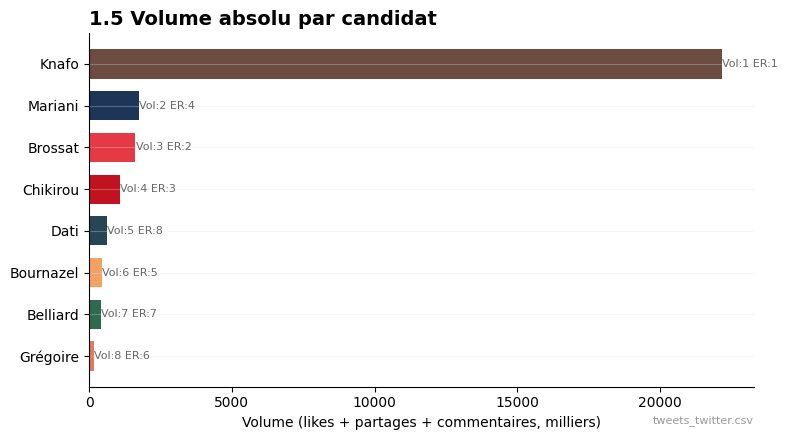

In [8]:
# Volume absolu : likes + shares + comments par candidat
key_map = {"Gregoire": "Grégoire"}
vol = tweets.assign(vol=(tweets["likes"].fillna(0) + tweets["shares"].fillna(0) + tweets["comments"].fillna(0)))
vol = vol.assign(cand_norm=vol["candidate"].map(lambda x: key_map.get(x, x)))
vol_by_cand = vol.groupby("cand_norm")["vol"].sum().sort_values(ascending=True)
vol_rank = vol_by_cand.rank(ascending=False).astype(int)
er_ranks = er_summary.set_index("key")["er_median_pct"].rank(ascending=False).astype(int)
er_ranks["Grégoire"] = er_ranks.get("Gregoire", er_ranks.get("Grégoire", 8))

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [COLORS.get(k, "#888") for k in vol_by_cand.index]
ax.barh(range(len(vol_by_cand)), vol_by_cand.values / 1e3, color=colors, height=0.7)
ax.set_yticks(range(len(vol_by_cand)))
ax.set_yticklabels(vol_by_cand.index, fontsize=10)
ax.set_xlabel("Volume (likes + partages + commentaires, milliers)")
swiss_style(ax, "1.5 Volume absolu par candidat", source="tweets_twitter.csv")
for i, (k, v) in enumerate(vol_by_cand.items()):
    r_vol, r_er = vol_rank[k], er_ranks.get(k, 0)
    ax.text(v / 1e3 + 5, i, f"Vol:{int(r_vol)} ER:{int(r_er)}", fontsize=8, va="center", color="#666")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_05_volume_absolu.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 1.5 Momentum : qui accélère, qui décline ?

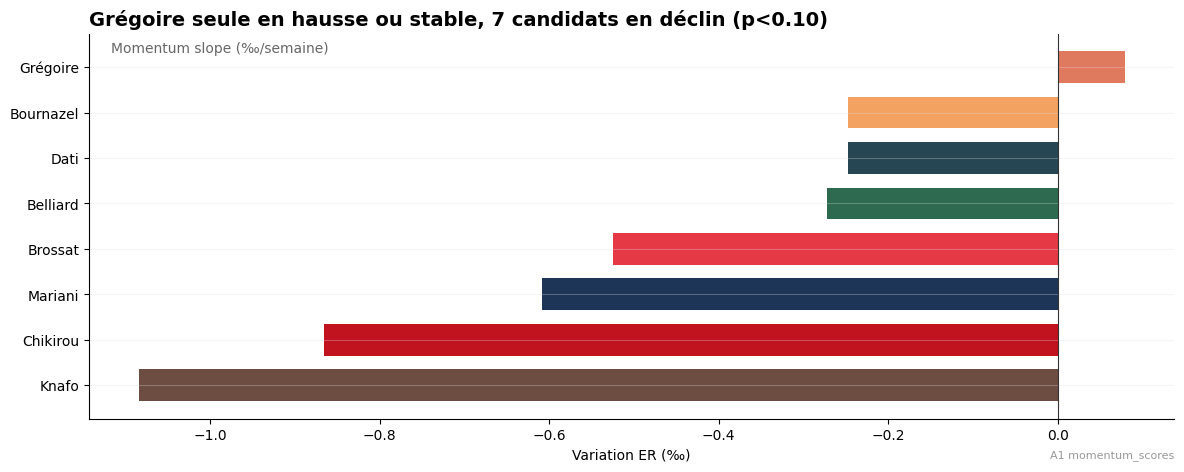

In [9]:
# Momentum (variation ER 8 dernières semaines vs historique, Twitter)
if momentum is not None:
    mom_tw = momentum[momentum["platform"] == "twitter"].copy()
    mom_tw["key"] = mom_tw["candidate_id"].map(ID_TO_KEY)
    mom_tw = mom_tw.sort_values("momentum_slope", ascending=True)
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = [COLORS.get(k, "#333") for k in mom_tw["key"]]
    ax.barh(mom_tw["key"], mom_tw["momentum_slope"] * 1000, color=colors, height=0.7)
    ax.axvline(0, color="#333", lw=0.8)
    swiss_style(ax, "Grégoire seule en hausse ou stable, 7 candidats en déclin (p<0.10)", "Momentum slope (‰/semaine)", "A1 momentum_scores")
    ax.set_xlabel("Variation ER (‰)")
    fig.savefig(FIG_DIR / "01_momentum.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 1.5bis Timeline ER (small multiples)

Huit subplots, un par candidat : évolution de l'ER médian hebdomadaire.

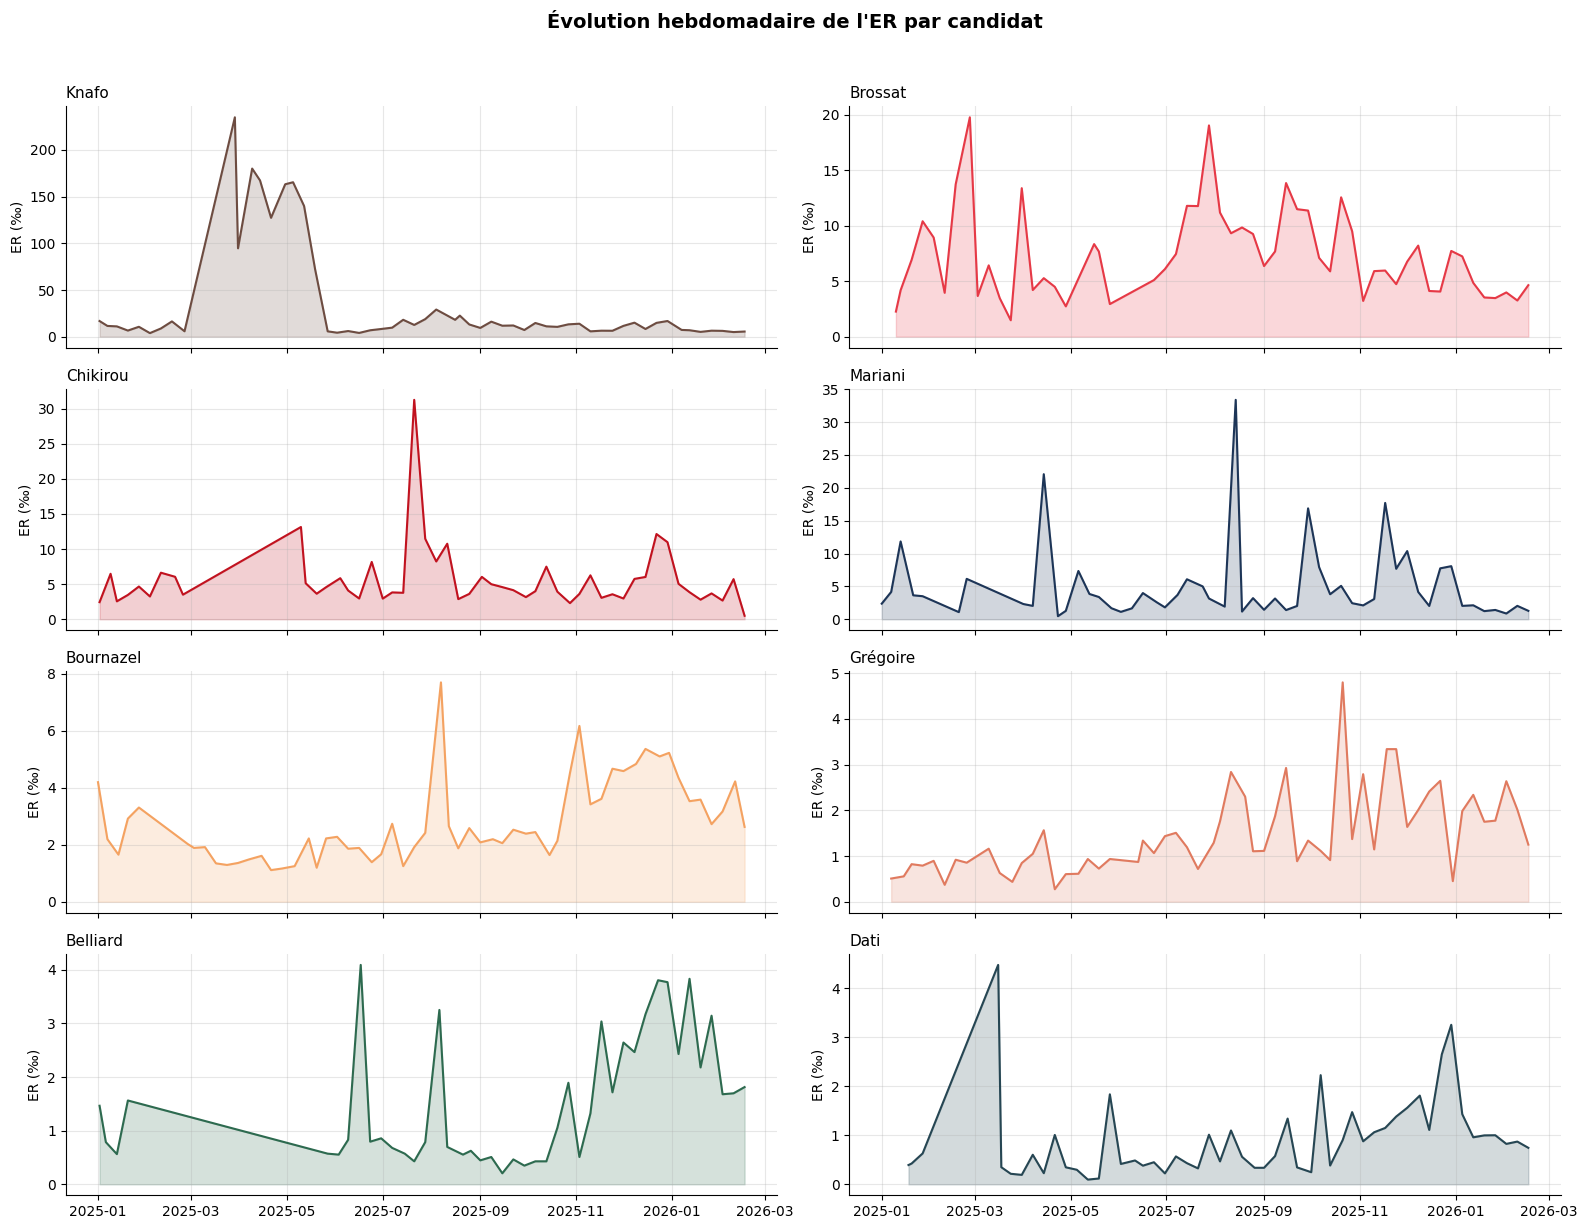

In [10]:
# Timeline ER, small multiples (8 subplots)
if weekly_tw is not None:
    wt = weekly_tw.copy()
    wt["key"] = wt["candidate_id"].map(ID_TO_KEY)
    wt["er_pct"] = wt["er_median"] * 1000
    wt["week_start"] = pd.to_datetime(wt["week_start"])
    fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
    axes = axes.flatten()
    for i, c in enumerate(KEYS_ER):
        sub = wt[wt["key"] == c]
        if len(sub) == 0:
            continue
        ax = axes[i]
        ax.plot(sub["week_start"], sub["er_pct"], color=COLORS.get(c, "#333"), lw=1.5)
        ax.fill_between(sub["week_start"], sub["er_pct"], alpha=0.2, color=COLORS.get(c, "#333"))
        ax.set_title(c, fontsize=11, loc="left")
        ax.set_ylabel("ER (‰)")
        ax.grid(True, alpha=0.3)
    plt.suptitle("Évolution hebdomadaire de l'ER par candidat", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    fig.savefig(FIG_DIR / "01_timeline_er.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 1.5ter Rythme de publication

Quand postent-ils ? Communication institutionnelle (lun-ven 9h-18h) vs réactivité (soir, week-end).

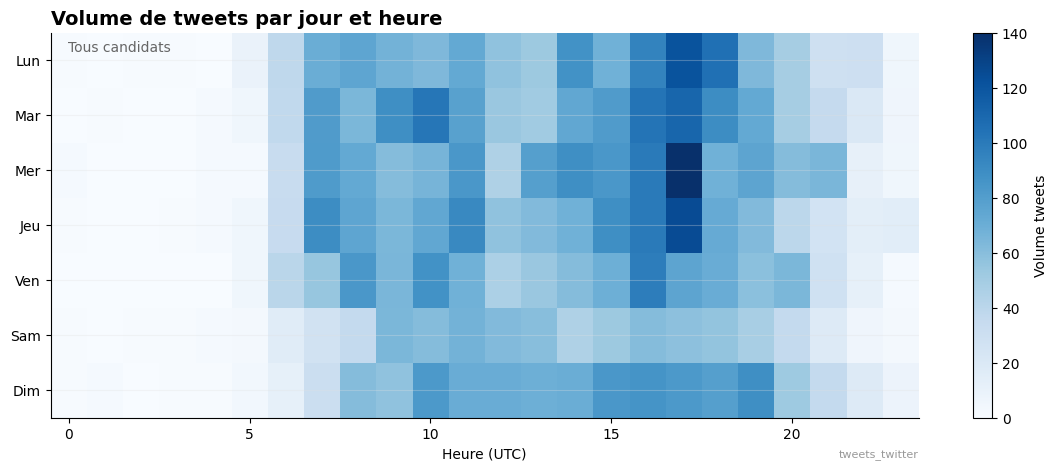

In [11]:
# Heatmap volume jour × heure (0=lundi, 23=23h)
tweets["hour"] = tweets["ts_parsed"].dt.hour
tweets["dow"] = tweets["ts_parsed"].dt.dayofweek
hm = tweets.groupby(["dow", "hour"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(hm.values, aspect="auto", cmap="Blues", interpolation="nearest")
ax.set_yticks(range(7))
ax.set_yticklabels(["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"])
ax.set_xlabel("Heure (UTC)")
plt.colorbar(im, ax=ax, label="Volume tweets")
swiss_style(ax, "Volume de tweets par jour et heure", "Tous candidats", "tweets_twitter")
fig.savefig(FIG_DIR / "01_heatmap_rythme.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 1.5quater Volume vs engagement

Poster plus dilue-t-il l'ER ? Scatter tweets/semaine × ER médian avec Spearman.

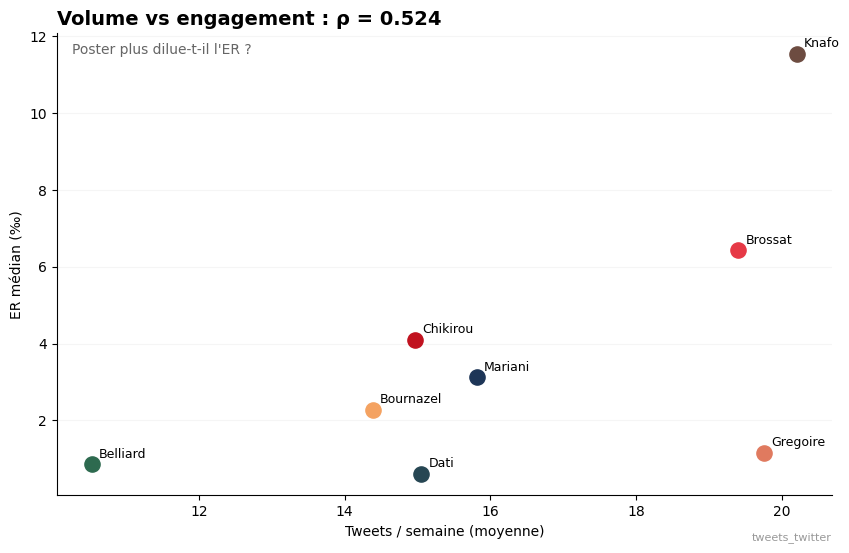

In [12]:
# Scatter volume × ER
from scipy import stats
vol = tweets.groupby("candidate").size().reset_index(name="n_tweets")
vol = vol.merge(er_summary[["key", "er_median_pct"]], left_on="candidate", right_on="key", how="left")
vol["tweets_per_week"] = vol["n_tweets"] / max(1, (tweets["ts_parsed"].max() - tweets["ts_parsed"].min()).days / 7)
rho, p = stats.spearmanr(vol["tweets_per_week"], vol["er_median_pct"])
fig, ax = plt.subplots(figsize=(10, 6))
for _, r in vol.iterrows():
    ax.scatter(r["tweets_per_week"], r["er_median_pct"], c=COLORS.get(r["key"], "#333"), s=120, zorder=5)
    ax.annotate(r["key"], (r["tweets_per_week"], r["er_median_pct"]), xytext=(5, 5), textcoords="offset points", fontsize=9)
ax.set_xlabel("Tweets / semaine (moyenne)")
ax.set_ylabel("ER médian (‰)")
swiss_style(ax, f"Volume vs engagement : ρ = {rho:.3f}", "Poster plus dilue-t-il l'ER ?", "tweets_twitter")
fig.savefig(FIG_DIR / "01_volume_er.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 1.10 Engagement par format et longueur

Relation entre la longueur du tweet (nombre de caractères) et le taux d'engagement. Les tranches court/moyen/long permettent d'évaluer si les messages concis ou au contraire détaillés performent mieux.

In [13]:
# Longueur (caractères) et ER
tw = tweets.copy()
tw["len_chars"] = tw["text"].fillna("").str.len()
tw["er_pct"] = tw["engagement_rate"].fillna(0) * 10  # en ‰
tw["tranche"] = pd.cut(tw["len_chars"], bins=[0, 100, 200, 280, 500], labels=["Court (<100)", "Moyen (100-200)", "Long (200-280)", "Très long (>280)"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
# Scatter longueur x ER (échantillon pour lisibilité)
sample = tw.sample(min(2000, len(tw)), random_state=42)
for k in KEYS_ER[:4]:
    sub = sample[sample["candidate"] == k]
    if len(sub) > 0:
        axes[0].scatter(sub["len_chars"], sub["er_pct"], alpha=0.4, s=15, c=COLORS.get(k, "#888"), label=k)
for k in KEYS_ER[4:]:
    sub = sample[sample["candidate"] == k]
    if len(sub) > 0:
        axes[0].scatter(sub["len_chars"], sub["er_pct"], alpha=0.3, s=10, c=COLORS.get(k, "#888"), label=k)
axes[0].set_xlabel("Longueur (caractères)")
axes[0].set_ylabel("ER (‰)")
axes[0].legend(loc="upper right", fontsize=8)
swiss_style(axes[0], "1.10a Longueur × ER (échantillon)", source="tweets_twitter.csv")

# Boxplot ER par tranche
tw_valid = tw[tw["tranche"].notna()]
order = ["Court (<100)", "Moyen (100-200)", "Long (200-280)", "Très long (>280)"]
bp = axes[1].boxplot([tw_valid[tw_valid["tranche"] == t]["er_pct"] for t in order], patch_artist=True, labels=order)
for patch in bp["boxes"]:
    patch.set_facecolor("#f0f0f0")
axes[1].set_ylabel("ER (‰)")
swiss_style(axes[1], "1.10b ER médian par tranche de longueur", source="tweets_twitter.csv")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_10_engagement_format.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.close()

## 1.6 Synthèse

L'ER médian de Knafo (11,5‰) dépasse de cinq fois celui des sept autres candidats. Sa base Twitter est nationale plutôt que parisienne. Sur les huit dernières semaines, un seul candidat affiche une pente positive non significative : Grégoire. Les tweets les plus engageants portent sur les frontières, l'agriculture ou la critique des institutions européennes ; les annonces programmatiques locales génèrent moins de réactions.